This notebook records the PSF inspection and pedestal subtraction process for measured AIRR PSF data. It includes exploratory preprocessing trials, ROI selection investigation, pedestal estimation, subtraction, normalization, and profile visualization.

## Exploratory preprocessing trials

The following cells show the exploratory process used to decide how to estimate and remove the pedestal component. Several methods are compared before summarizing the final pipeline.

In [2]:
## 0 === Standard Startup Template ===
import os, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Project Path Setup ---
root = r"C:\AI_research"
psf_root = Path(root) / "Real_PSF"
psf_name = "251023_AC6mm_1920x1200"   
psf_csv_path = psf_root / f"{psf_name}.csv"
psf_img_path = psf_root / f"{psf_name}.png"
print("PSF CSV:", psf_csv_path)
print("PSF PNG:", psf_img_path)

# fail fast if paths are wrong
assert psf_csv_path.exists(), f"Missing PSF CSV: {psf_csv_path}"
assert psf_img_path.exists(), f"Missing PSF PNG: {psf_img_path}"


PSF CSV: C:\AI_research\Real_PSF\251023_AC6mm_1920x1200.csv
PSF PNG: C:\AI_research\Real_PSF\251023_AC6mm_1920x1200.png


In [3]:
#step 1 debugging
psf_full = np.loadtxt(psf_csv_path, delimiter=',').astype(np.float64)
print(psf_full.shape, psf_full.min(), psf_full.max(), psf_full.sum())


(1200, 1920) 0.0 987.2 17542738.000000004


In [4]:
## step 2 finding PSF center
import numpy as np

psf = psf_full

# Peak location (argmax)
peak_y, peak_x = np.unravel_index(np.argmax(psf), psf.shape)

# Center of mass (COM)
ys, xs = np.indices(psf.shape)
total = psf.sum()
com_y = (ys * psf).sum() / total
com_x = (xs * psf).sum() / total

print(f"peak (y,x): ({peak_y}, {peak_x})")
print(f"COM  (y,x): ({com_y:.2f}, {com_x:.2f})")
print(f"image center (y,x): ({psf.shape[0]/2:.1f}, {psf.shape[1]/2:.1f})")


peak (y,x): (604, 968)
COM  (y,x): (604.99, 956.60)
image center (y,x): (600.0, 960.0)


In [5]:
#Step 3 quick saturation check
sat_frac = np.mean(psf >= 1023)
print("fraction >= 1023 (saturated):", sat_frac)


fraction >= 1023 (saturated): 0.0


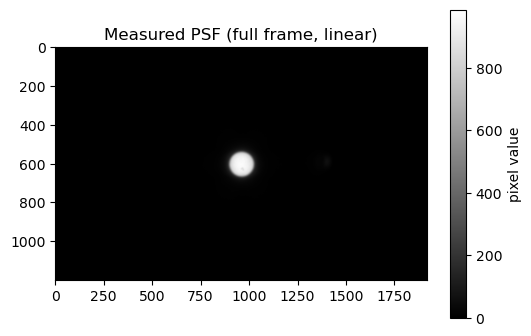

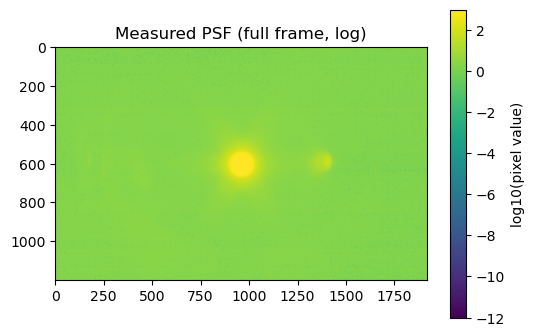

In [6]:
#Step 4 Visualize full frame
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(psf, cmap="gray")
plt.title("Measured PSF (full frame, linear)")
plt.colorbar(label="pixel value")
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(np.log10(psf + 1e-12), cmap="viridis")
plt.title("Measured PSF (full frame, log)")
plt.colorbar(label="log10(pixel value)")
plt.show()



psf_com shape: (401, 401) sum: 13334759.999999998 max: 987.2
psf_peak shape: (401, 401) sum: 13334799.399999999 max: 987.2


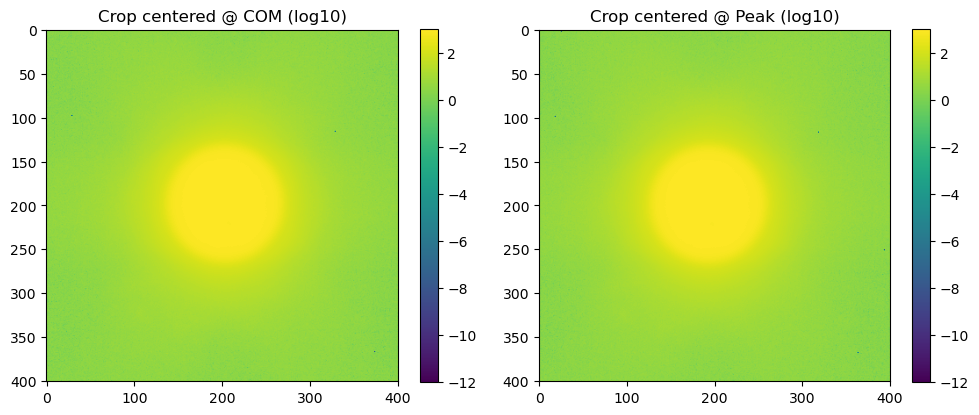

In [7]:
#step 4b crop kernel ROI
import numpy as np
import matplotlib.pyplot as plt

ksize = 401

def crop_odd(psf, cy, cx, ksize):
    assert ksize % 2 == 1, "ksize must be odd"
    r = ksize // 2
    cy = int(round(cy))
    cx = int(round(cx))
    y0, y1 = cy - r, cy + r + 1
    x0, x1 = cx - r, cx + r + 1
    return psf[y0:y1, x0:x1]

psf_com  = crop_odd(psf_full, 604.99, 956.60, ksize=ksize)
psf_peak = crop_odd(psf_full, 604,    968,    ksize=ksize)

print("psf_com shape:", psf_com.shape, "sum:", psf_com.sum(), "max:", psf_com.max())
print("psf_peak shape:", psf_peak.shape, "sum:", psf_peak.sum(), "max:", psf_peak.max())

# visualize log (best for tails)
eps = 1e-12
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(psf_com + eps), cmap="viridis")
plt.title("Crop centered @ COM (log10)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(np.log10(psf_peak + eps), cmap="viridis")
plt.title("Crop centered @ Peak (log10)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [8]:
#Step 5 Quantifying the Ghost
import numpy as np

psf = psf_full.copy()

flat = psf.ravel()
idxs = np.argpartition(flat, -8)[-8:]   # 10 largest pixels (unordered)
idxs = idxs[np.argsort(flat[idxs])[::-1]] # sort descending

H, W = psf.shape
peaks = [(int(i//W), int(i%W), float(flat[i])) for i in idxs]
for p in peaks[:10]:
    print("peak y,x,val:", p)


peak y,x,val: (604, 968, 987.2)
peak y,x,val: (610, 967, 984.3)
peak y,x,val: (605, 958, 984.1)
peak y,x,val: (608, 949, 983.9)
peak y,x,val: (599, 956, 983.8)
peak y,x,val: (609, 959, 983.7)
peak y,x,val: (611, 961, 983.2)
peak y,x,val: (607, 953, 982.9)


In [9]:
#Step 6 Isolate main lobe
import numpy as np

py, px = 604, 968
H, W = psf.shape
ys, xs = np.indices(psf.shape)
r = np.sqrt((ys - py)**2 + (xs - px)**2)

R = 250  # start with 250 px, adjust if needed
mask = (r <= R)

psf_local = psf * mask
total = psf_local.sum()

com_y = (ys * psf_local).sum() / total
com_x = (xs * psf_local).sum() / total

print("Local COM (masked):", com_y, com_x)
print("Local sum fraction:", total / psf.sum())


Local COM (masked): 602.9372066535087 960.3101963628231
Local sum fraction: 0.7655262251536787


In [10]:
#Step 7 crop kernel using local COM
def crop_odd(psf, cy, cx, ksize=201):
    r = ksize // 2
    cy = int(round(cy)); cx = int(round(cx))
    return psf[cy-r:cy+r+1, cx-r:cx+r+1]

ksize = 201
k_main = crop_odd(psf, com_y, com_x, ksize)
print(k_main.shape, k_main.min(), np.median(k_main), k_main.max(), k_main.sum())


(201, 201) 4.2 77.7 987.2 12712641.8


In [11]:
#step 8 Background pedestal subtraction before normalization
k = k_main.astype(np.float64)

bg = np.percentile(k, 5)   # try 1, 5, 10 later if needed
k_bs = k - bg
k_bs[k_bs < 0] = 0

print("bg:", bg)
print("after subtract: min/median/max/sum =",
      float(k_bs.min()), float(np.median(k_bs)), float(k_bs.max()), float(k_bs.sum()))


bg: 11.4
after subtract: min/median/max/sum = 0.0 66.3 975.8000000000001 12256265.700000001


In [12]:
#step 9 Normalization
k_norm = k_bs / (k_bs.sum() + 1e-12)
print("norm sum:", float(k_norm.sum()), "norm max:", float(k_norm.max()))


norm sum: 1.0 norm max: 7.961642019559024e-05


In [13]:
# step 10 Check local sum fraction
psf = psf_full.astype(np.float64)
bg_full = np.percentile(psf, 5)
psf_bs = psf - bg_full
psf_bs[psf_bs < 0] = 0

# recompute local sum fraction with same mask
py, px = 604, 968
ys, xs = np.indices(psf_bs.shape)
r = np.sqrt((ys - py)**2 + (xs - px)**2)
mask = (r <= 250)

frac = psf_bs[mask].sum() / (psf_bs.sum() + 1e-12)
print("bg_full:", bg_full, "local frac after bg-sub:", frac)


bg_full: 0.7 local frac after bg-sub: 0.8332946279512538


In [14]:
#step 11 estimate bg from border ring
import numpy as np

k = k_main.astype(np.float64)

border = 10  # pixels
ring = np.concatenate([
    k[:border, :].ravel(),
    k[-border:, :].ravel(),
    k[:, :border].ravel(),
    k[:, -border:].ravel()
])

bg_edge_median = np.median(ring)
bg_edge_p10    = np.percentile(ring, 10)

print("bg_edge_median:", bg_edge_median)
print("bg_edge_p10   :", bg_edge_p10)

# subtract and clamp
k_bs = k - bg_edge_median
k_bs[k_bs < 0] = 0

print("after edge-sub: min/median/max/sum =",
      float(k_bs.min()), float(np.median(k_bs)), float(k_bs.max()), float(k_bs.sum()))


bg_edge_median: 18.5
bg_edge_p10   : 8.4
after edge-sub: min/median/max/sum = 0.0 59.2 968.7 11996706.7


In [15]:
#step 12 check if crop is too small
k401 = crop_odd(psf_full, 602.94, 960.31, ksize=401).astype(np.float64)

ring401 = np.concatenate([
    k401[:border, :].ravel(),
    k401[-border:, :].ravel(),
    k401[:, :border].ravel(),
    k401[:, -border:].ravel()
])

print("401 ring median:", np.median(ring401), "ring p10:", np.percentile(ring401, 10))
print("401 min/median/max:", float(k401.min()), float(np.median(k401)), float(k401.max()))


401 ring median: 2.7 ring p10: 1.6
401 min/median/max: 0.0 5.1 987.2


In [16]:
#step 13 Build a clean kernel
k = k401.astype(np.float64)

border = 10
ring = np.concatenate([
    k[:border, :].ravel(),
    k[-border:, :].ravel(),
    k[:, :border].ravel(),
    k[:, -border:].ravel()
])

bg = np.median(ring)   # use median: robust
k_bs = k - bg
k_bs[k_bs < 0] = 0

k_norm = k_bs / (k_bs.sum() + 1e-12)

print("bg:", bg)
print("after sub: min/median/max/sum =", float(k_bs.min()), float(np.median(k_bs)), float(k_bs.max()), float(k_bs.sum()))
print("norm sum:", float(k_norm.sum()), "norm max:", float(k_norm.max()))


bg: 2.7
after sub: min/median/max/sum = 0.0 2.3999999999999995 984.5 12917858.999999996
norm sum: 1.0000000000000002 norm max: 7.621231970406244e-05


In [17]:
#Step14 verify if kernel is centered
ys, xs = np.indices(k_norm.shape)
total = k_norm.sum()
com_y = (ys * k_norm).sum() / total
com_x = (xs * k_norm).sum() / total

cy = (k_norm.shape[0]-1)/2
cx = (k_norm.shape[1]-1)/2

print("kernel COM:", com_y, com_x)
print("center:", cy, cx)
print("COM offset (px):", np.sqrt((com_y-cy)**2 + (com_x-cx)**2))


kernel COM: 199.9123854657339 199.99983855683826
center: 200.0 200.0
COM offset (px): 0.08761468300781079


In [18]:
#step 15 decide ROI size again
k_clean_401 = k_norm

k_clean_201 = crop_odd(k_clean_401, cy, cx, ksize=201)
k_clean_201 = k_clean_201 / (k_clean_201.sum() + 1e-12)

print("201 sum:", float(k_clean_201.sum()), "max:", float(k_clean_201.max()))


201 sum: 0.999999999998975 max: 7.811285623272802e-05


In [19]:
#step 16 save the PSF as npy
from pathlib import Path
import numpy as np

OUT_DIR = Path(r"C:\AI_research\Real_PSF\processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUT_DIR / f"{psf_name}_kernel401_bgsub_norm.npy", k_norm)         # 401x401
np.save(OUT_DIR / f"{psf_name}_kernel201_bgsub_norm.npy", k_clean_201)    # 201x201

print("Saved to:", OUT_DIR)


Saved to: C:\AI_research\Real_PSF\processed


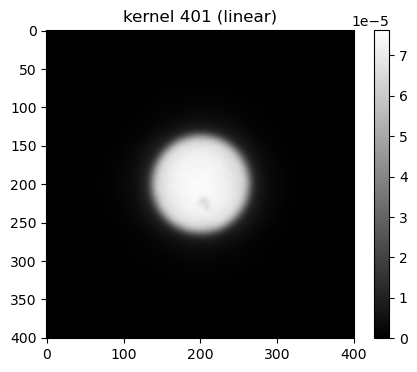

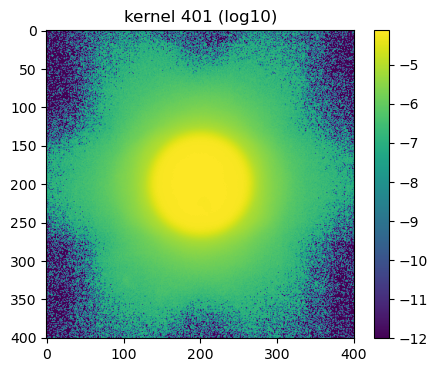

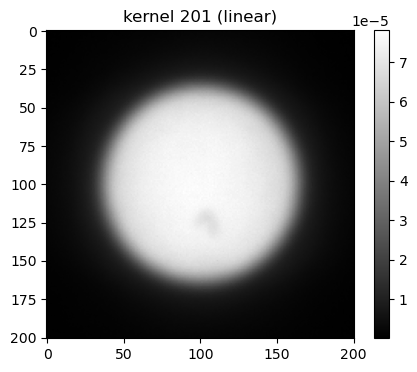

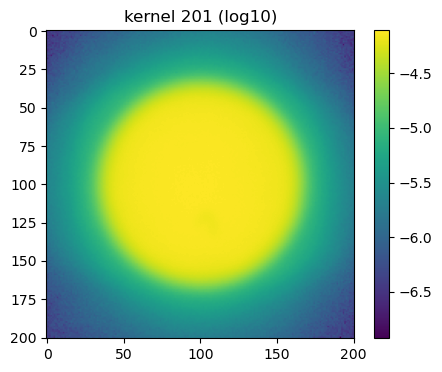

In [20]:
#step 17 visualize the kenels
import matplotlib.pyplot as plt
eps = 1e-12

for name, k in [("401", k_norm), ("201", k_clean_201)]:
    plt.figure(figsize=(5,4))
    plt.imshow(k, cmap="gray")
    plt.colorbar()
    plt.title(f"kernel {name} (linear)")
    plt.show()

    plt.figure(figsize=(5,4))
    plt.imshow(np.log10(k + eps), cmap='viridis', origin='upper')
    plt.colorbar()
    plt.title(f"kernel {name} (log10)")
    plt.show()


## Final cleaned preprocessing pipeline

The previous section shows the exploratory process.  
The following cell summarizes a cleaner PSF preprocessing pipeline:

1. Estimate the center of the bright PSF core
2. Estimate the 1/e² radius from the measured PSF
3. Set the square ROI half-width using a multiplier of the 1/e² radius
4. Crop the square ROI around the estimated center
5. Estimate the pedestal using the median of the ROI border-ring region
6. Subtract the pedestal and clip negative values to zero
7. Normalize the PSF so that the sum equals 1
8. Create 401×401 and 201×201 compact kernels for comparison with the earlier fixed-ROI workflow

psf_full shape: (1200, 1920)
psf_full min/max: 0.0 987.2
Argmax pixel (py, px): (604, 968)
Argmax value: 987.2
Bright core geometric center (cy, cx): (602.9183441726025, 960.1997522452772)
Bright core weighted center  (cy, cx): (602.9170348015887, 960.1089505204876)
Bright core mask pixel count: 9687
Crop center used (cy, cx): (602.9183441726025, 960.1997522452772)


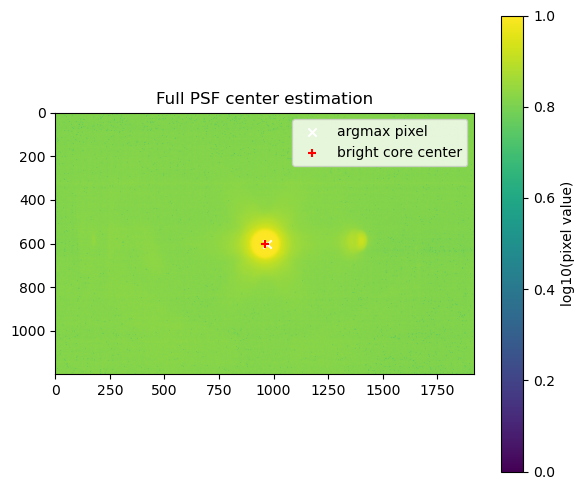

Preliminary full-frame bg: 1.7
1/e^2 threshold: 133.37292162968183
Estimated r_1/e^2 (95th percentile): 70.80747191965806
ROI multiplier: 3.0
ROI half-width: 213
Square ROI size: 427


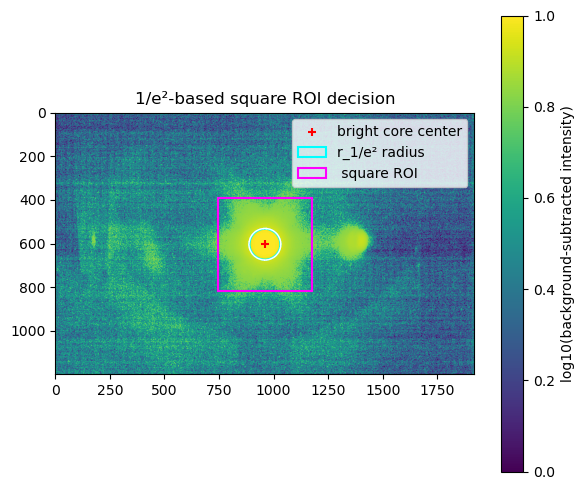

K_roi_raw shape: (427, 427)
K_roi_raw min/max: 0.0 987.2
K_roi_raw sum: 13390037.000000002
Argmax inside K_roi_raw: (214, 221)
ROI center: (213, 213)
Argmax offset from ROI center: (1, 8)
Estimated pedestal bg: 2.5
Border ring min/median/max: 0.0 2.5 7.1
After subtract + clip:
K_roi_bs min/max: 0.0 984.7
K_roi_bs sum: 12953590.699999997
zero_frac: 0.18174837793219947
K_roi shape: (427, 427)
K_roi sum: 1.0000000000000004
K_roi max: 7.601753234336794e-05
K_roi COM (y, x): (212.91064006677308, 213.00471165110994)
K_roi center: (213, 213)
K_roi COM offset (px): 0.08948406183505946
K401_raw shape: (401, 401) K401 sum: 1.0 K401 max: 7.606599790953303e-05
K201_raw shape: (201, 201) K201 sum: 0.9999999999999999 K201 max: 7.807866817123448e-05
Ready to save: K_roi, K401, and K201


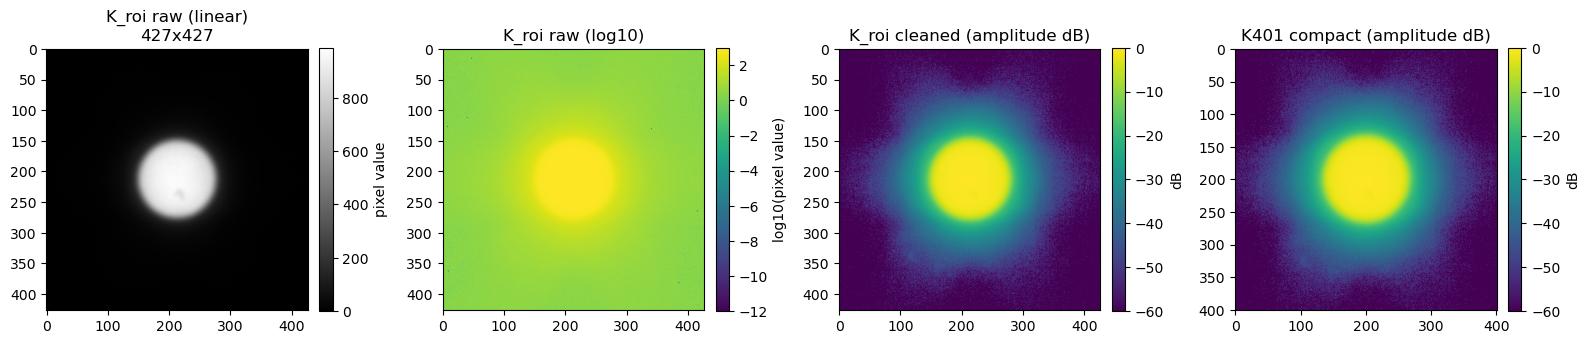

In [22]:
# ===================== PSF_Inspection "Clean Pipeline" =====================
# Goal:
# Turn a measured PSF (psf_full, 1200x1920) into a clean convolution kernel.
#
# Main flow:
# 1. Estimate the center of the bright PSF core
# 2. Estimate 1/e^2 radius from the measured PSF
# 3. Set ROI half-width = 3 × r_1/e^2
# 4. Crop a square ROI around the estimated center
# 5. Estimate pedestal from the ROI border ring
# 6. Subtract pedestal and clip negative values to zero
# 7. Normalize to unit-sum PSF kernel
# 8. Also create 401x401 and 201x201 compact kernels for comparison / later plots
# 9. Visualize raw and cleaned PSFs

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# --------------------- settings ---------------------

BRIGHT_CORE_THRESHOLD_REL = 0.80
ROI_MULTIPLIER = 3.0
RADIUS_PERCENTILE = 95
BORDER_RING_WIDTH = 10
PRELIM_FULLFRAME_BORDER = 50

# Keep amplitude-style display mapping because it gives clearer visual contrast.
DISPLAY_DB_MODE = "amplitude"  # "amplitude" uses 20*log10, "intensity" uses 10*log10


# --------------------- helpers ---------------------

def crop_odd(img, cy, cx, ksize):
    """Crop an odd-sized square ROI centered at (cy, cx)."""
    assert ksize % 2 == 1
    h = ksize // 2
    cyi, cxi = int(round(cy)), int(round(cx))

    y0, y1 = cyi - h, cyi + h + 1
    x0, x1 = cxi - h, cxi + h + 1

    if y0 < 0 or x0 < 0 or y1 > img.shape[0] or x1 > img.shape[1]:
        raise ValueError(
            f"Crop out of bounds: y={y0}:{y1}, x={x0}:{x1}, image shape={img.shape}"
        )

    return img[y0:y1, x0:x1].copy()


def odd_size_from_half_width(half_width):
    """Convert half-width to odd kernel size."""
    half_width = int(np.ceil(half_width))
    return 2 * half_width + 1


def max_odd_crop_size(img, cy, cx):
    """Largest possible odd crop size around (cy, cx) without going outside the image."""
    cyi, cxi = int(round(cy)), int(round(cx))
    max_half = min(cyi, img.shape[0] - 1 - cyi, cxi, img.shape[1] - 1 - cxi)
    return 2 * int(max_half) + 1


def estimate_bright_core_center(img, threshold_rel=0.80):
    """
    Estimate the center of the bright PSF core.

    This is better than using only np.argmax when the maximum region is a bright
    circular core / plateau rather than a single point.
    """
    img = img.astype(np.float64)
    max_val = img.max()

    mask = img >= threshold_rel * max_val

    if mask.sum() == 0:
        raise ValueError("Bright core mask is empty. Lower threshold_rel.")

    yy, xx = np.nonzero(mask)

    # Geometric center of bright core region
    cy_geom = yy.mean()
    cx_geom = xx.mean()

    # Intensity-weighted center inside bright core region
    weights = img[mask]
    cy_weighted = np.sum(yy * weights) / np.sum(weights)
    cx_weighted = np.sum(xx * weights) / np.sum(weights)

    return (cy_geom, cx_geom), (cy_weighted, cx_weighted), mask


def estimate_fullframe_border_bg(img, border=50):
    """
    Preliminary background estimate from the outer full-frame border.
    This is used only to estimate the PSF width / 1/e^2 radius.
    """
    top = img[:border, :]
    bottom = img[-border:, :]
    left = img[border:-border, :border]
    right = img[border:-border, -border:]

    vals = np.concatenate([
        top.ravel(),
        bottom.ravel(),
        left.ravel(),
        right.ravel()
    ])

    return np.median(vals)


def estimate_r_1e2_from_mask(img, cy, cx, bg=0.0, percentile=95):
    """
    Estimate r_1/e^2 from background-subtracted intensity.

    Because measured PSFs can contain small hot spots or local stray light,
    the radius is estimated using a percentile of the pixels above I_peak/e^2
    instead of the absolute maximum radius.
    """
    signal = img.astype(np.float64) - float(bg)
    signal[signal < 0] = 0.0

    peak = signal.max()
    if peak <= 0:
        raise ValueError("Peak is zero after preliminary background subtraction.")

    threshold = peak / (np.e ** 2)

    yy, xx = np.mgrid[:img.shape[0], :img.shape[1]]
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    mask = signal >= threshold

    if mask.sum() == 0:
        raise ValueError("1/e^2 mask is empty.")

    r_1e2 = np.percentile(rr[mask], percentile)

    return r_1e2, threshold, mask, signal


def border_ring_values(K, ring=10):
    """
    Collect border ring pixels for pedestal estimation.

    Corners are not duplicated:
    - top/bottom use full width
    - left/right use only middle rows
    """
    top = K[:ring, :]
    bottom = K[-ring:, :]
    left = K[ring:-ring, :ring]
    right = K[ring:-ring, -ring:]

    return np.concatenate([
        top.ravel(),
        bottom.ravel(),
        left.ravel(),
        right.ravel()
    ])


def pedestal_subtract_and_clip(K, bg):
    """Subtract constant pedestal bg and clip negative values to zero."""
    out = K.astype(np.float64) - float(bg)
    out[out < 0] = 0.0
    return out


def unit_sum_normalize(K):
    """Normalize so sum(K)=1."""
    s = K.sum()
    if s <= 0:
        raise ValueError("Kernel sum <= 0 after pedestal subtraction. bg too large or crop invalid.")
    return K / s


def to_log_db_relative_peak(K, floor_db=-60, mode="amplitude"):
    """
    Display dB map where peak = 0 dB.

    This is for visualization only.
    - mode="amplitude": 20*log10, visually stronger contrast
    - mode="intensity": 10*log10, intensity-style PSF display
    """
    eps = 1e-12
    Kp = K / (K.max() + eps)

    if mode == "amplitude":
        log_db = 20 * np.log10(np.maximum(Kp, eps))
    elif mode == "intensity":
        log_db = 10 * np.log10(np.maximum(Kp, eps))
    else:
        raise ValueError("mode must be 'amplitude' or 'intensity'.")

    return np.clip(log_db, floor_db, 0)


def center_of_mass(K):
    """Center of mass for sanity check, returned as (y, x)."""
    K = np.asarray(K, dtype=np.float64)
    s = K.sum()
    if s <= 0:
        return (np.nan, np.nan)

    ys, xs = np.mgrid[:K.shape[0], :K.shape[1]]
    return ((ys * K).sum() / s, (xs * K).sum() / s)


# ===================== PIPELINE START =====================

print("psf_full shape:", psf_full.shape)
print("psf_full min/max:", psf_full.min(), psf_full.max())

# Step 1) Estimate PSF core center before cropping
# The measured PSF has a bright circular core, so using only argmax can be unstable.
py_max, px_max = np.unravel_index(np.argmax(psf_full), psf_full.shape)

core_center_geom, core_center_weighted, core_mask = estimate_bright_core_center(
    psf_full,
    threshold_rel=BRIGHT_CORE_THRESHOLD_REL
)

# Use geometric center of bright core for cropping
cy, cx = core_center_geom

# Optional: manually checked center can be used instead
# cy, cx = 604.99, 956.60

print("Argmax pixel (py, px):", (py_max, px_max))
print("Argmax value:", psf_full[py_max, px_max])
print("Bright core geometric center (cy, cx):", core_center_geom)
print("Bright core weighted center  (cy, cx):", core_center_weighted)
print("Bright core mask pixel count:", core_mask.sum())
print("Crop center used (cy, cx):", (cy, cx))

# Visual check for full-frame center estimation
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(np.maximum(psf_full, 1e-12)), cmap="viridis")
plt.scatter([px_max], [py_max], c="white", marker="x", label="argmax pixel")
plt.scatter([cx], [cy], c="red", marker="+", label="bright core center")
plt.title("Full PSF center estimation")
plt.colorbar(label="log10(pixel value)")
plt.legend()
plt.tight_layout()
plt.show()

# Step 2) Estimate 1/e^2 radius and determine square ROI size
bg_prelim = estimate_fullframe_border_bg(psf_full, border=PRELIM_FULLFRAME_BORDER)

r_1e2, threshold_1e2, mask_1e2, psf_signal_prelim = estimate_r_1e2_from_mask(
    psf_full,
    cy=cy,
    cx=cx,
    bg=bg_prelim,
    percentile=RADIUS_PERCENTILE
)

roi_half_width = int(np.ceil(ROI_MULTIPLIER * r_1e2))
roi_size = odd_size_from_half_width(roi_half_width)

max_size = max_odd_crop_size(psf_full, cy, cx)

if roi_size > max_size:
    print(f"WARNING: requested ROI size {roi_size} exceeds maximum possible {max_size}.")
    print(f"Using maximum possible ROI size: {max_size}")
    roi_size = max_size
    roi_half_width = roi_size // 2

print("Preliminary full-frame bg:", bg_prelim)
print("1/e^2 threshold:", threshold_1e2)
print(f"Estimated r_1/e^2 ({RADIUS_PERCENTILE}th percentile):", r_1e2)
print("ROI multiplier:", ROI_MULTIPLIER)
print("ROI half-width:", roi_half_width)
print("Square ROI size:", roi_size)

# Visual check for 1/e^2 ROI decision
# Cyan circle = estimated r_1/e^2 radius
# Magenta square = Square ROI crop boundary
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(np.maximum(psf_signal_prelim, 1e-12)), cmap="viridis")
plt.contour(mask_1e2, levels=[0.5], colors="white", linewidths=1)
plt.scatter([cx], [cy], c="red", marker="+", label="bright core center")

# r_1/e^2 radius as circle
circle_1e2 = Circle(
    (cx, cy),
    r_1e2,
    edgecolor="cyan",
    facecolor="none",
    linewidth=1.5,
    label="r_1/e² radius"
)
plt.gca().add_patch(circle_1e2)

# Square ROI boundary
x0 = cx - roi_half_width
y0 = cy - roi_half_width

roi_square = Rectangle(
    (x0, y0),
    roi_size,
    roi_size,
    edgecolor="magenta",
    facecolor="none",
    linewidth=1.5,
    label=" square ROI"
)
plt.gca().add_patch(roi_square)

plt.title("1/e²-based square ROI decision")
plt.colorbar(label="log10(background-subtracted intensity)")
plt.legend()
plt.tight_layout()
plt.show()

# Step 3) Crop objective square ROI around the estimated core center
K_roi_raw = crop_odd(psf_full, cy, cx, ksize=roi_size)

print("K_roi_raw shape:", K_roi_raw.shape)
print("K_roi_raw min/max:", K_roi_raw.min(), K_roi_raw.max())
print("K_roi_raw sum:", K_roi_raw.sum())

# Check where the brightest pixel is inside the crop
roi_py, roi_px = np.unravel_index(np.argmax(K_roi_raw), K_roi_raw.shape)
roi_center = (K_roi_raw.shape[0] // 2, K_roi_raw.shape[1] // 2)

print("Argmax inside K_roi_raw:", (roi_py, roi_px))
print("ROI center:", roi_center)
print("Argmax offset from ROI center:", (roi_py - roi_center[0], roi_px - roi_center[1]))

# Step 4) Estimate pedestal from objective ROI border ring
ring = border_ring_values(K_roi_raw, ring=BORDER_RING_WIDTH)
bg = np.median(ring)

print("Estimated pedestal bg:", bg)
print("Border ring min/median/max:", ring.min(), np.median(ring), ring.max())

# Step 5) Subtract pedestal and clip negative values to zero
K_roi_bs = pedestal_subtract_and_clip(K_roi_raw, bg)

print("After subtract + clip:")
print("K_roi_bs min/max:", K_roi_bs.min(), K_roi_bs.max())
print("K_roi_bs sum:", K_roi_bs.sum())
print("zero_frac:", (K_roi_bs == 0).mean())

# Step 6) Unit-sum normalize to make objective convolution PSF kernel
K_roi = unit_sum_normalize(K_roi_bs)

print("K_roi shape:", K_roi.shape)
print("K_roi sum:", K_roi.sum())
print("K_roi max:", K_roi.max())

com_yx = center_of_mass(K_roi)
center_yx = (K_roi.shape[0] // 2, K_roi.shape[1] // 2)
com_offset = np.sqrt((com_yx[0] - center_yx[0])**2 + (com_yx[1] - center_yx[1])**2)

print("K_roi COM (y, x):", com_yx)
print("K_roi center:", center_yx)
print("K_roi COM offset (px):", com_offset)

# Step 7) Create 401x401 and 201x201 compact kernels for comparison / later plotting
# These are cropped from the same full measured PSF using the same center and pedestal value.
# They are useful for comparing with the earlier fixed-ROI workflow.
K401_raw = crop_odd(psf_full, cy, cx, ksize=401)
K401_bs = pedestal_subtract_and_clip(K401_raw, bg)
K401 = unit_sum_normalize(K401_bs)

K201_raw = crop_odd(psf_full, cy, cx, ksize=201)
K201_bs = pedestal_subtract_and_clip(K201_raw, bg)
K201 = unit_sum_normalize(K201_bs)

print("K401_raw shape:", K401_raw.shape, "K401 sum:", K401.sum(), "K401 max:", K401.max())
print("K201_raw shape:", K201_raw.shape, "K201 sum:", K201.sum(), "K201 max:", K201.max())

# Step 8) Save kernels if needed
# np.save("kernel_roi_bgsub_norm.npy", K_roi)
# np.save("kernel401_bgsub_norm.npy", K401)
# np.save("kernel201_bgsub_norm.npy", K201)

print("Ready to save: K_roi, K401, and K201")

# Step 9) Visualization
eps_plot = 1e-12  # only for log visualization

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(K_roi_raw, cmap="gray")
plt.title(f"K_roi raw (linear)\n{roi_size}x{roi_size}")
plt.colorbar(fraction=0.046, pad=0.04, label="pixel value")

plt.subplot(1, 4, 2)
plt.imshow(np.log10(np.maximum(K_roi_raw, eps_plot)), cmap="viridis")
plt.title("K_roi raw (log10)")
plt.colorbar(fraction=0.046, pad=0.04, label="log10(pixel value)")

plt.subplot(1, 4, 3)
plt.imshow(to_log_db_relative_peak(K_roi, floor_db=-60, mode=DISPLAY_DB_MODE), cmap="viridis", vmin=-60, vmax=0)
plt.title(f"K_roi cleaned ({DISPLAY_DB_MODE} dB)")
plt.colorbar(label="dB", fraction=0.046, pad=0.04)

plt.subplot(1, 4, 4)
plt.imshow(to_log_db_relative_peak(K401, floor_db=-60, mode=DISPLAY_DB_MODE), cmap="viridis", vmin=-60, vmax=0)
plt.title(f"K401 compact ({DISPLAY_DB_MODE} dB)")
plt.colorbar(label="dB", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ===================== PIPELINE END =====================

## Appendix: validation and diagnostic checks

The following cells were used to validate the processed PSF and check how the kernel behaves in convolution and profile visualization. These cells are kept as part of the research process.

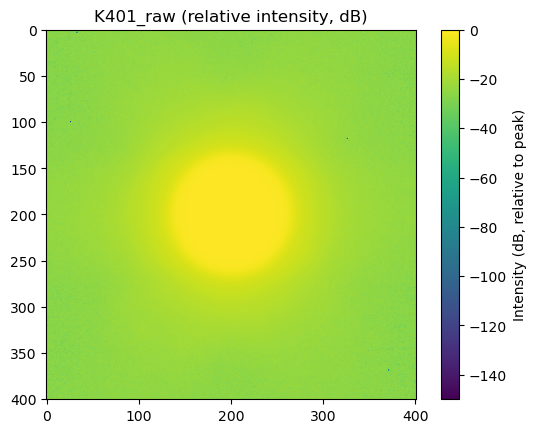

In [24]:
I_ref = K401_raw.max()
plt.imshow(10 * np.log10((K401_raw + 1e-12) / I_ref), cmap="viridis")
plt.colorbar(label="Intensity (dB, relative to peak)")
plt.title("K401_raw (relative intensity, dB)")
plt.show()



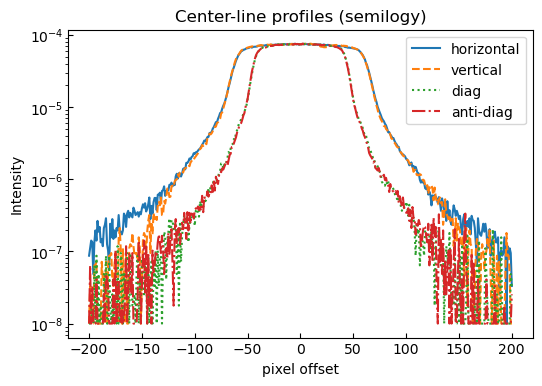

In [25]:
K = K401  # cleaned kernel
cy, cx = 200, 200

h = K[cy, :]
v = K[:, cx]
d1 = np.diag(K)              # main diagonal
d2 = np.diag(np.fliplr(K))   # other diagonal

x = np.arange(len(h)) - cx

plt.figure(figsize=(6,4))
plt.semilogy(x, h + 1e-8, label="horizontal")
plt.semilogy(x, v + 1e-8, label="vertical", linestyle="--")
plt.semilogy(x, d1 + 1e-8, label="diag", linestyle=":")
plt.semilogy(x, d2 + 1e-8, label="anti-diag", linestyle="-.")
plt.title("Center-line profiles (semilogy)")
plt.xlabel("pixel offset")
plt.ylabel("Intensity")
plt.tick_params(direction="in")
plt.grid(False)
plt.legend()
plt.show()


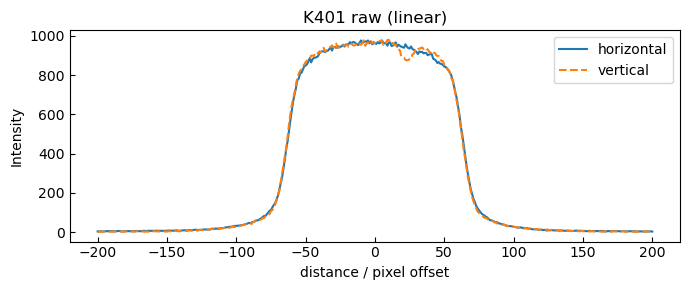

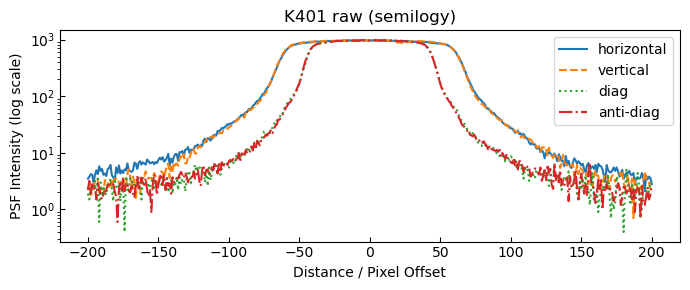

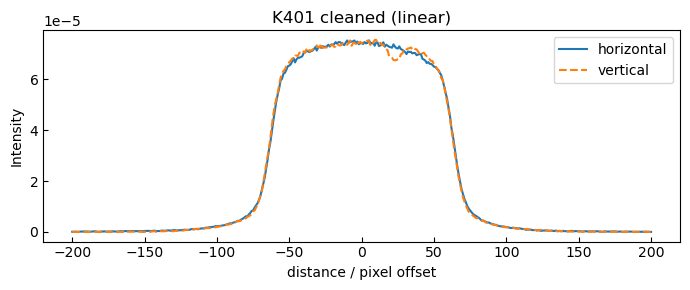

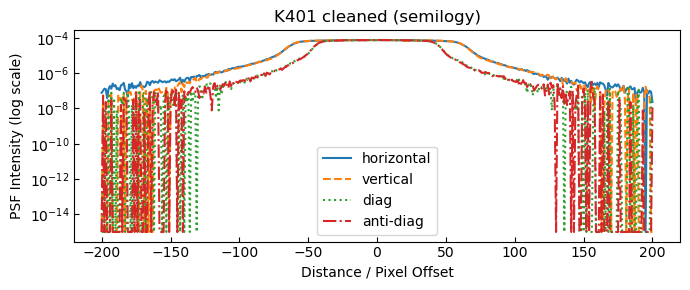

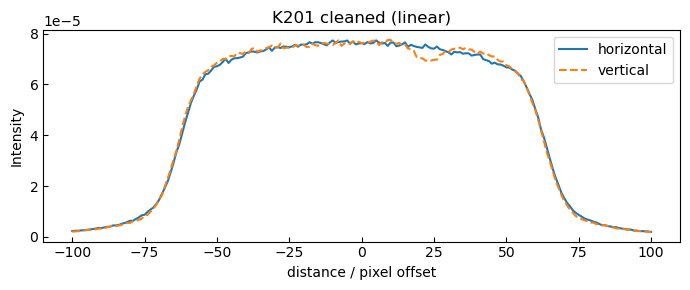

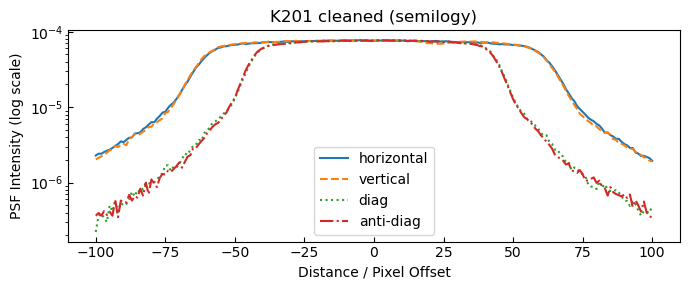

In [26]:
## expended plots
import numpy as np
import matplotlib.pyplot as plt

def plot_psf_1d_profiles(K, title="", floor=1e-15):
    K = np.asarray(K, np.float64)
    H, W = K.shape
    cy, cx = H//2, W//2

    # 4 cuts
    horiz = K[cy, :]
    vert  = K[:, cx]
    diag  = np.diag(K)
    anti  = np.diag(np.fliplr(K))

    x = np.arange(-(W//2), W//2 + 1)

    # --- Linear (core) ---
    plt.figure(figsize=(7,3))
    plt.plot(x, horiz, label="horizontal")
    plt.plot(x, vert,  label="vertical", linestyle="--")
    plt.title(title + " (linear)")
    plt.xlabel("distance / pixel offset"); plt.ylabel("Intensity")
    plt.tick_params(direction="in")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Semilogy (tails) ---
    plt.figure(figsize=(7,3))
    plt.semilogy(x, np.maximum(horiz, floor), label="horizontal")
    plt.semilogy(x, np.maximum(vert,  floor), label="vertical", linestyle="--")
    plt.semilogy(x, np.maximum(diag,  floor), label="diag", linestyle=":")
    plt.semilogy(x, np.maximum(anti,  floor), label="anti-diag", linestyle="-.")
    plt.title(title + " (semilogy)")
    plt.xlabel("Distance / Pixel Offset"); plt.ylabel("PSF Intensity (log scale)")
    plt.tick_params(direction="in")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_psf_1d_profiles(K401_raw, title="K401 raw")
plot_psf_1d_profiles(K401,     title="K401 cleaned")
plot_psf_1d_profiles(K201,     title="K201 cleaned")



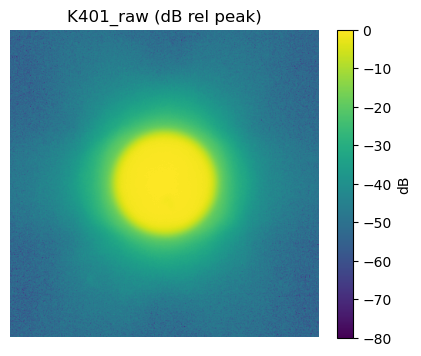

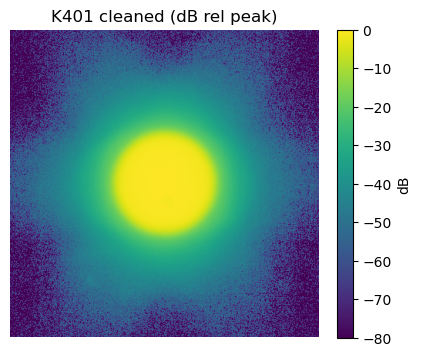

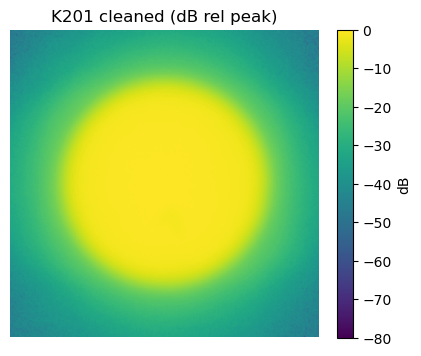

In [27]:
def show_db_rel_peak(K, floor_db=-80, title=""):
    K = np.asarray(K, np.float64)
    Kp = K / (K.max() + 1e-12)
    db = 20*np.log10(Kp + 1e-12)
    plt.figure(figsize=(5,4))
    plt.imshow(np.clip(db, floor_db, 0), cmap="viridis", vmin=floor_db, vmax=0)
    plt.title(title if title else f"dB rel peak (floor {floor_db} dB)")
    plt.axis("off")
    plt.colorbar(label="dB")
    plt.show()

show_db_rel_peak(K401_raw, floor_db=-80, title="K401_raw (dB rel peak)")
show_db_rel_peak(K401,     floor_db=-80, title="K401 cleaned (dB rel peak)")
show_db_rel_peak(K201,     floor_db=-80, title="K201 cleaned (dB rel peak)")
